In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# Load the dataset
file_path = 'retail_store_inventory.csv'
df = pd.read_csv(file_path)

In [11]:
# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Extract new time-based features
df['Hour'] = df['Date'].dt.hour  # Extract hour
df['Day'] = df['Date'].dt.day    # Extract day of the month
df['Weekday'] = df['Date'].dt.weekday  # Extract weekday (0 = Monday, 6 = Sunday)
df['Month'] = df['Date'].dt.month  # Extract month

# Verify the change
df.dtypes

Date                  datetime64[ns]
Store ID                      object
Product ID                    object
Category                      object
Region                        object
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Demand Forecast              float64
Price                        float64
Discount                       int64
Weather Condition             object
Holiday/Promotion              int64
Competitor Pricing           float64
Seasonality                   object
Hour                           int32
Day                            int32
Weekday                        int32
Month                          int32
dtype: object

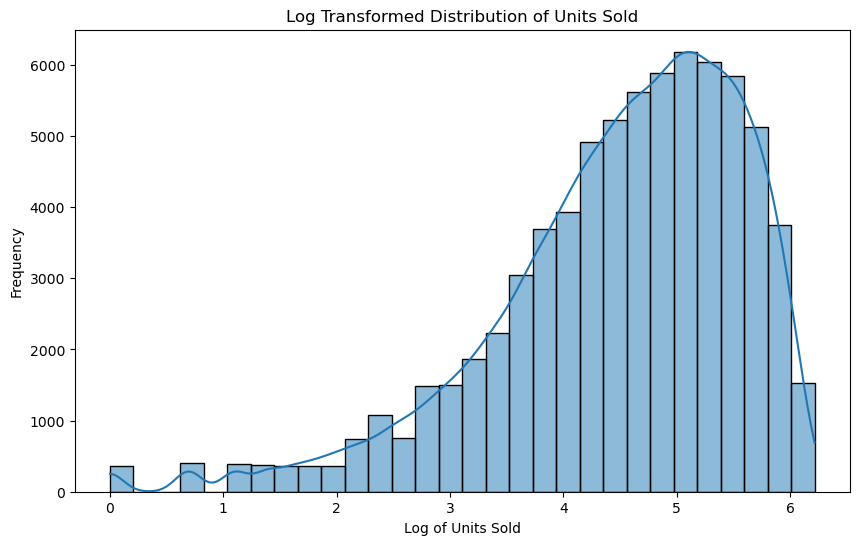

Skewness of Log Units Sold: -1.1148972357284723


In [12]:
# Apply log transformation to the target variable
df['Log Units Sold'] = np.log1p(df['Units Sold'])

# Visualize the new distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Log Units Sold'], kde=True, bins=30)
plt.title('Log Transformed Distribution of Units Sold')
plt.xlabel('Log of Units Sold')
plt.ylabel('Frequency')
plt.show()

# Check the skewness again
log_skew = skew(df['Log Units Sold'])
print(f"Skewness of Log Units Sold: {log_skew}")

In [13]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assuming df is your DataFrame

# Define feature columns and target for the transformed target
X = df.drop(columns=['Units Sold', 'Log Units Sold', 'Date'])  # Drop 'Units Sold', 'Log Units Sold', and 'Date'
y = df['Log Units Sold']  # Target is now the log-transformed variable

# 1. Handle categorical columns (encode them)
categorical_columns = ['Store ID','Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']  # Example columns to encode

# Apply OneHotEncoder for categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns),
        ('num', StandardScaler(), ['Price','Units Ordered', 'Demand Forecast','Holiday/Promotion', 'Discount', 'Competitor Pricing', 'Inventory Level', 'Hour', 'Day', 'Month', 'Weekday'])
    ])

# 2. Split the data into training and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create a pipeline with preprocessing and XGBoost model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=6))
])

# 4. Train the model
model.fit(X_train, y_train)

# 5. Make predictions
y_pred = model.predict(X_test)

# 6. Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'R-squared: {r2}')

Mean Absolute Error: 0.14336924271127008
Mean Squared Error: 0.08051257018887785
Root Mean Squared Error: 0.2837473703646923
R-squared: 0.9359297700585015


Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END regressor__learning_rate=0.1, regressor__max_depth=6, regressor__n_estimators=50, regressor__subsample=0.8; total time=   0.7s
[CV] END regressor__learning_rate=0.2, regressor__max_depth=3, regressor__n_estimators=100, regressor__subsample=0.8; total time=   0.7s
[CV] END regressor__learning_rate=0.1, regressor__max_depth=6, regressor__n_estimators=50, regressor__subsample=0.8; total time=   0.8s
[CV] END regressor__learning_rate=0.1, regressor__max_depth=6, regressor__n_estimators=50, regressor__subsample=0.8; total time=   0.8s
[CV] END regressor__learning_rate=0.2, regressor__max_depth=3, regressor__n_estimators=100, regressor__subsample=0.8; total time=   0.8s
[CV] END regressor__learning_rate=0.2, regressor__max_depth=3, regressor__n_estimators=100, regressor__subsample=0.8; total time=   0.6s
[CV] END regressor__learning_rate=0.1, regressor__max_depth=3, regressor__n_estimators=100, regressor__subsample=1.0; to

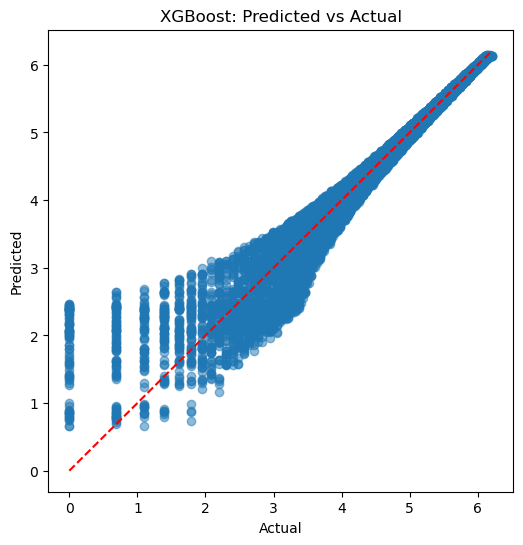

Model saved as 'best_xgboost_model.pkl'


In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib

# Data preparation (replace 'df' with your actual dataframe)
X = df.drop(columns=['Units Sold', 'Log Units Sold', 'Date'])
y = df['Log Units Sold']

# Categorical columns
categorical_columns = ['Store ID','Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns),
    ('num', StandardScaler(), ['Price','Units Ordered', 'Demand Forecast','Holiday/Promotion', 'Discount', 'Competitor Pricing', 'Inventory Level', 'Hour', 'Day', 'Month', 'Weekday'])
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the pipeline with XGBoost model
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(objective='reg:squarederror'))
])

# Hyperparameter tuning using RandomizedSearchCV
param_grid = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [3, 6, 9],
    'regressor__learning_rate': [0.01, 0.1, 0.2],
    'regressor__subsample': [0.8, 1.0]
}

search = RandomizedSearchCV(model, param_distributions=param_grid, n_iter=10, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)
search.fit(X_train, y_train)

# Print the best parameters found by RandomizedSearchCV
print("Best XGBoost params:", search.best_params_)

# Predict and evaluate the model
y_pred = search.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse}\nMAE: {mae}\nR2: {r2}')

# Plot Predicted vs Actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('XGBoost: Predicted vs Actual')
plt.show()

In [ ]:
# Save the best model to a .pkl file
best_model = search.best_estimator_
joblib.dump(best_model, 'best_xgboost_model.pkl')
print("Model saved as 'best_xgboost_model.pkl'")